# Pavement Identification Using Hyperspectral Data

This notebook implements a supervised classification approach to identify pavements in Brooklyn using hyperspectral imagery.

## Overview
- **Data**: NYU TuckMapping Mission1 NE-SW (288 bands)
- **Ground Truth**: NYC Land Cover Raster 2017
- **Method**: Random Forest classification
- **Area**: Small test region in Brooklyn


In [1]:
import numpy as np
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
import pandas as pd
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


## 1. Data Loading and Inspection

Load the hyperspectral data and land cover data.


In [2]:
# Path to hyperspectral data
hyperspectral_path = "NYU_TuckMapping_20190511_Mission1_NE-SW_288Bands.pix"

print("Hyperspectral data:")
with rasterio.open(hyperspectral_path) as src:
    print(f"  Bands: {src.count}")
    print(f"  Width: {src.width}, Height: {src.height}")
    print(f"  CRS: {src.crs}")
    print(f"  Transform: {src.transform}")
    print(f"  Data type: {src.dtypes[0]}")


Hyperspectral data:
  Bands: 288
  Width: 6419, Height: 8001
  CRS: EPSG:3178
  Transform: | 0.30, 0.00, 581674.50|
| 0.00,-0.30, 4500699.60|
| 0.00, 0.00, 1.00|
  Data type: uint16


## 2. Extract Test Area

Extract a small area for processing (e.g., 500x500 pixels).


In [3]:
# Define test area size
test_size_x = 500  # pixels
test_size_y = 500  # pixels

# Starting coordinates (adjust based on your data)
start_x = 0
start_y = 0

# Load hyperspectral test area
with rasterio.open(hyperspectral_path) as src:
    # Read a subset of bands (all 288 if memory allows, or sample every nth band)
    band_subset = list(range(1, min(101, src.count + 1)))  # Use first 100 bands for speed
    hyperspectral_data = src.read(band_subset, window=rasterio.windows.Window(start_x, start_y, test_size_x, test_size_y))
    hyperspectral_profile = src.profile

print(f"Extracted hyperspectral data shape: {hyperspectral_data.shape}")


Extracted hyperspectral data shape: (100, 500, 500)


## 3. Visualize RGB Composite and Extract Training Samples

Since we don't have ground truth data, we'll use the hyperspectral data to create an RGB composite and manually extract training samples based on visual inspection.


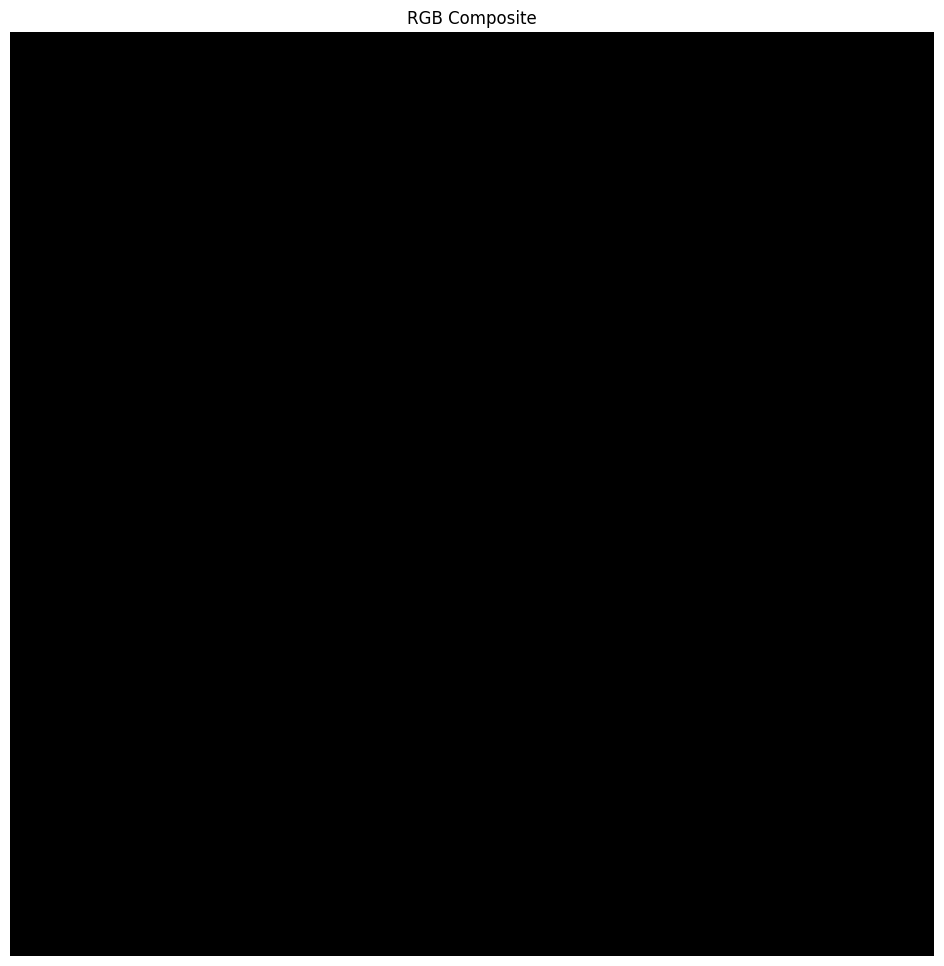

RGB composite shape: (500, 500, 3)


In [4]:
# Create an RGB composite from hyperspectral bands for visualization
# Approximate RGB bands - adjust indices based on your sensor
# Note: hyperspectral_data is 0-indexed (dimensions: bands, height, width)
red_band_idx = 90   # Adjust based on your sensor
green_band_idx = 40   # Adjust based on your sensor
blue_band_idx = 5    # Adjust based on your sensor

# Ensure indices are within range (0-indexed for numpy array)
red_band_idx = min(red_band_idx, hyperspectral_data.shape[0] - 1)
green_band_idx = min(green_band_idx, hyperspectral_data.shape[0] - 1)
blue_band_idx = min(blue_band_idx, hyperspectral_data.shape[0] - 1)

# Create RGB composite
rgb_composite = np.zeros((hyperspectral_data.shape[1], hyperspectral_data.shape[2], 3))
rgb_composite[:, :, 0] = hyperspectral_data[red_band_idx, :, :]    # Red
rgb_composite[:, :, 1] = hyperspectral_data[green_band_idx, :, :]  # Green
rgb_composite[:, :, 2] = hyperspectral_data[blue_band_idx, :, :]   # Blue

# Normalize to 0-1 range
for i in range(3):
    band = rgb_composite[:, :, i]
    rgb_composite[:, :, i] = (band - band.min()) / (band.max() - band.min() + 1e-10)

# Display the RGB composite
plt.figure(figsize=(12, 12))
plt.imshow(rgb_composite)
plt.title('RGB Composite')
plt.axis('off')
plt.show()

print(f"RGB composite shape: {rgb_composite.shape}")


## 4. Alternative: Use Unsupervised Clustering for Initial Segmentation

Since we don't have ground truth labels, we can use K-means clustering to identify different surface types automatically.


Performing K-means clustering to identify surface types...
Total pixels: 250000
Valid pixels: 250000
Sampling 50000 pixels for clustering

Clustering complete. 5 clusters identified.


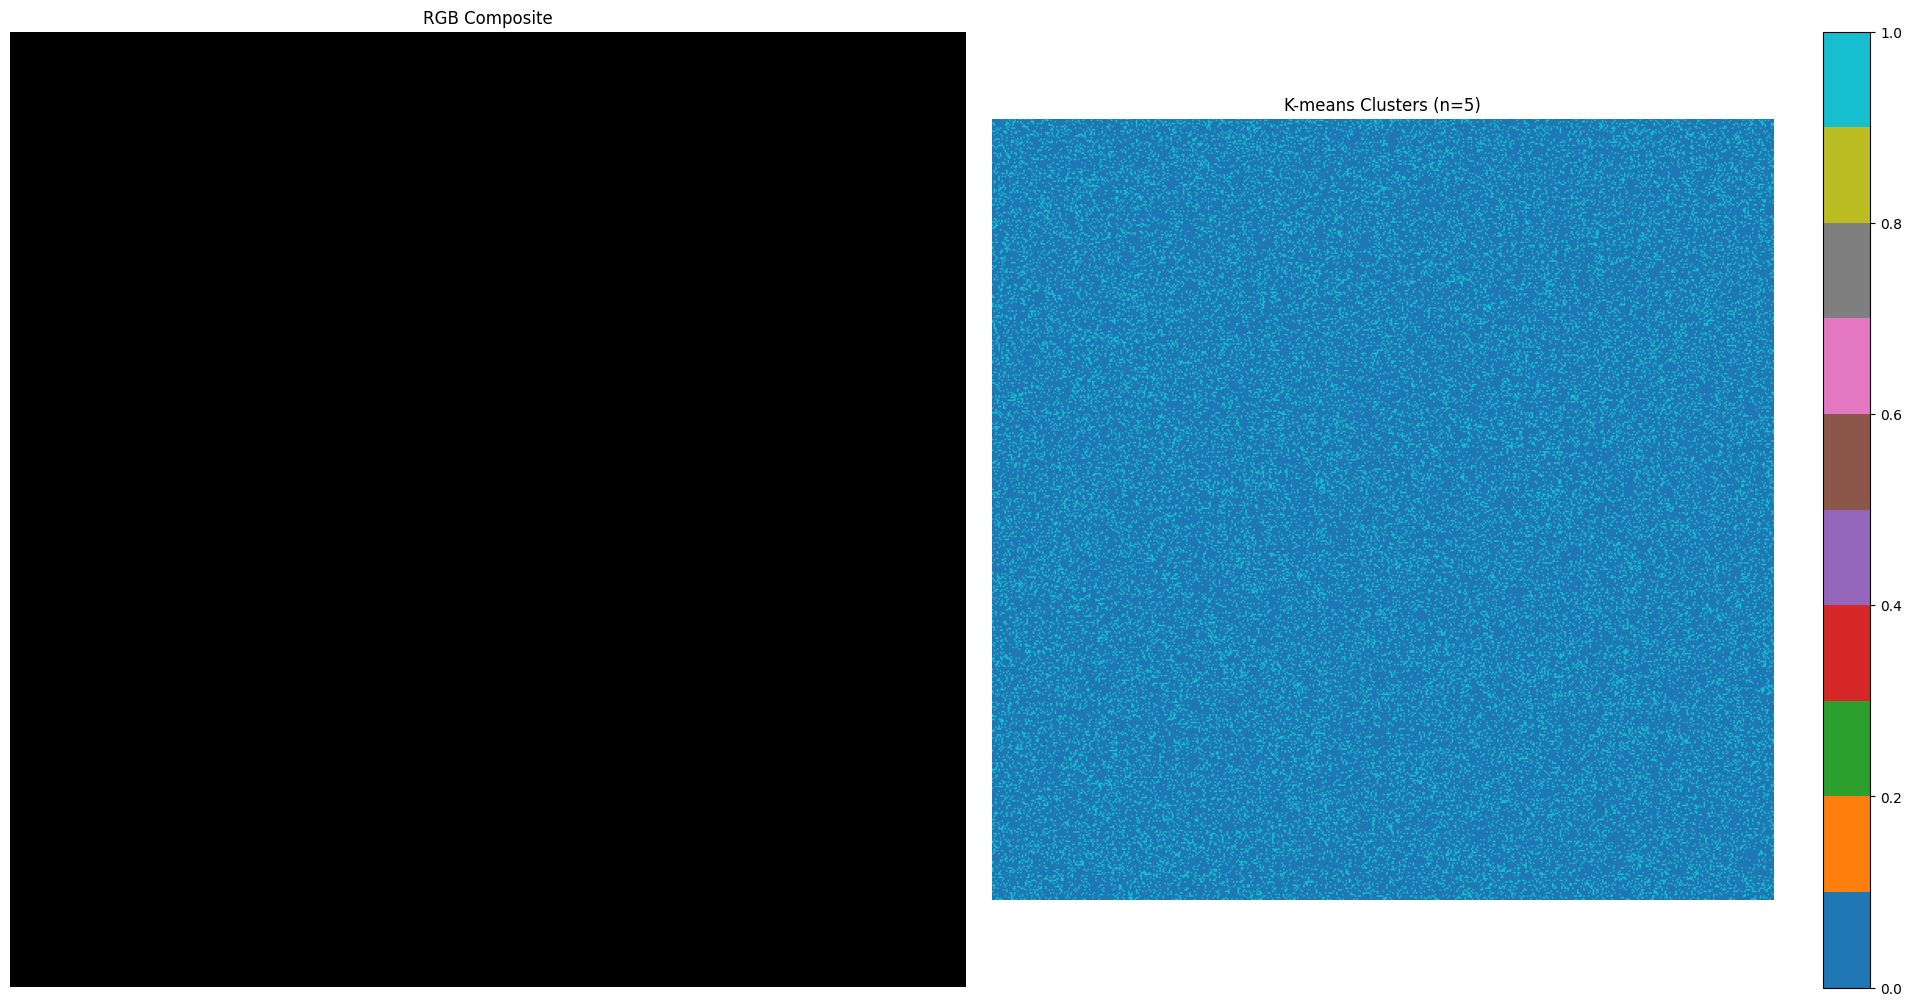


Next: Manually identify which cluster(s) represent pavement based on visual inspection.


In [5]:
# Perform K-means clustering to identify different surface types
# This will help identify pavement automatically

print("Performing K-means clustering to identify surface types...")

# Reshape hyperspectral data
n_bands = hyperspectral_data.shape[0]
n_pixels = hyperspectral_data.shape[1] * hyperspectral_data.shape[2]

X = hyperspectral_data.transpose(1, 2, 0).reshape(n_pixels, n_bands)

# Remove NaN values
valid_mask = ~np.isnan(X).any(axis=1)
X_clean = X[valid_mask]
valid_indices = np.where(valid_mask)[0]

print(f"Total pixels: {n_pixels}")
print(f"Valid pixels: {len(X_clean)}")

# Sample pixels for faster clustering (optional - comment out to use all pixels)
if len(X_clean) > 50000:
    sample_indices = np.random.choice(len(X_clean), 50000, replace=False)
    X_cluster = X_clean[sample_indices]
    print(f"Sampling {len(X_cluster)} pixels for clustering")
else:
    X_cluster = X_clean

# Perform K-means clustering (k=5 for different surface types)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

print(f"\nClustering complete. {n_clusters} clusters identified.")

# Visualize clusters
if len(X_clean) > 50000:
    # Map back to full image
    cluster_map_full = np.zeros(n_pixels, dtype=int)
    cluster_map_full[valid_indices[sample_indices]] = cluster_labels + 1
    cluster_map = cluster_map_full.reshape(hyperspectral_data.shape[1], hyperspectral_data.shape[2])
else:
    cluster_map_full = np.zeros(n_pixels, dtype=int)
    cluster_map_full[valid_indices] = cluster_labels + 1
    cluster_map = cluster_map_full.reshape(hyperspectral_data.shape[1], hyperspectral_data.shape[2])

# Visualize clusters and RGB side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(rgb_composite)
axes[0].set_title('RGB Composite')
axes[0].axis('off')

im = axes[1].imshow(cluster_map, cmap='tab10')
axes[1].set_title(f'K-means Clusters (n={n_clusters})')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

print("\nNext: Manually identify which cluster(s) represent pavement based on visual inspection.")


## 5. Identify Pavement Clusters and Create Binary Mask

Based on the cluster visualization, identify which cluster(s) represent pavement and create a binary classification.


Clusters identified as pavement: [1, 2]
Pavement pixels: 50000
Non-pavement pixels: 200000


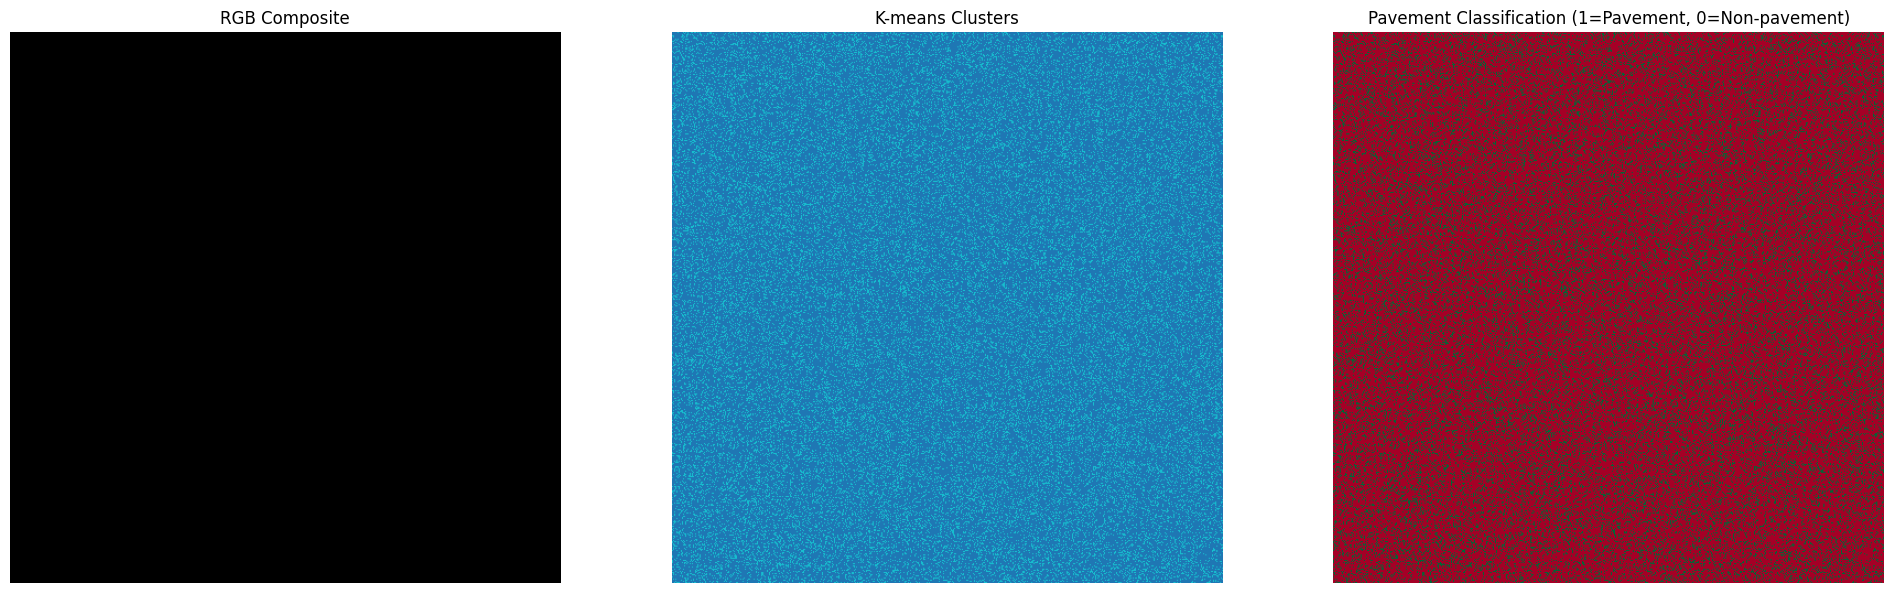

In [6]:
# After visual inspection, identify which clusters represent pavement
# UPDATE THESE CLUSTER NUMBERS based on your inspection of the cluster map above
pavement_clusters = [1, 2]  # Example: assuming clusters 1 and 2 are pavement
# Update this list after inspecting the cluster visualization

# Create binary mask: 1 = pavement, 0 = non-pavement
pavement_mask = np.isin(cluster_map, pavement_clusters).astype(int)

print(f"Clusters identified as pavement: {pavement_clusters}")
print(f"Pavement pixels: {np.sum(pavement_mask)}")
print(f"Non-pavement pixels: {np.sum(pavement_mask == 0)}")

# Visualize the binary classification
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(rgb_composite)
axes[0].set_title('RGB Composite')
axes[0].axis('off')

axes[1].imshow(cluster_map, cmap='tab10')
axes[1].set_title('K-means Clusters')
axes[1].axis('off')

axes[2].imshow(pavement_mask, cmap='RdYlGn')
axes[2].set_title('Pavement Classification (1=Pavement, 0=Non-pavement)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## 4. Prepare Training Data

Extract spectral features for training.


In [7]:
# Reshape hyperspectral data: (bands, height, width) -> (height*width, bands)
n_bands = hyperspectral_data.shape[0]
n_pixels = hyperspectral_data.shape[1] * hyperspectral_data.shape[2]

X = hyperspectral_data.transpose(1, 2, 0).reshape(n_pixels, n_bands)
y = pavement_mask.flatten()

print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")

# Remove NaN values
valid_mask = ~np.isnan(X).any(axis=1)
X_clean = X[valid_mask]
y_clean = y[valid_mask]

# Balance classes if needed (sample more if severely imbalanced)
from sklearn.utils import resample

# Split into pavement and non-pavement
pavement_indices = np.where(y_clean == 1)[0]
non_pavement_indices = np.where(y_clean == 0)[0]

print(f"Pavement pixels: {len(pavement_indices)}")
print(f"Non-pavement pixels: {len(non_pavement_indices)}")

# Sample balanced dataset if needed (limit to reasonable size)
max_samples = min(50000, len(non_pavement_indices))
sampled_non_pavement = np.random.choice(non_pavement_indices, max_samples, replace=False)

# Combine indices
indices = np.concatenate([pavement_indices, sampled_non_pavement])
X_balanced = X_clean[indices]
y_balanced = y_clean[indices]

print(f"\nBalanced dataset:")
print(f"  Pavement: {np.sum(y_balanced == 1)}")
print(f"  Non-pavement: {np.sum(y_balanced == 0)}")


Feature matrix shape: (250000, 100)
Label vector shape: (250000,)
Pavement pixels: 50000
Non-pavement pixels: 200000

Balanced dataset:
  Pavement: 50000
  Non-pavement: 50000


## 5. Train Classifier

Train Random Forest classifier on spectral signatures.


In [8]:
# Split data: 70% training, 30% validation
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Train Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_train)

# Predict on test set
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-pavement', 'Pavement']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)


Training samples: 70000
Test samples: 30000

Accuracy: 0.4982

Classification Report:
              precision    recall  f1-score   support

Non-pavement       0.50      1.00      0.67     14945
    Pavement       0.00      0.00      0.00     15055

    accuracy                           0.50     30000
   macro avg       0.25      0.50      0.33     30000
weighted avg       0.25      0.50      0.33     30000


Confusion Matrix:
[[14945     0]
 [15055     0]]


## 6. Apply Classifier to Full Test Area

Classify the entire test area.


In [9]:
# Apply classifier to all pixels
# Use batches to avoid memory issues
batch_size = 10000
predictions = []

for i in range(0, len(X), batch_size):
    batch = X[i:min(i+batch_size, len(X))]
    batch_valid = ~np.isnan(batch).any(axis=1)
    
    batch_pred = np.zeros(len(batch))
    batch_pred[~batch_valid] = -999  # NoData value
    
    if np.any(batch_valid):
        batch_pred[batch_valid] = rf_classifier.predict(batch[batch_valid])
    
    predictions.append(batch_pred)
    
    if (i // batch_size + 1) % 10 == 0:
        print(f"Processed {i + batch_size}/{len(X)} pixels")

all_predictions = np.concatenate(predictions)
classification_map = all_predictions.reshape(hyperspectral_data.shape[1], hyperspectral_data.shape[2])

print(f"Classification map shape: {classification_map.shape}")
print(f"Pavement pixels in map: {np.sum(classification_map == 1)}")


Processed 100000/250000 pixels
Processed 200000/250000 pixels
Classification map shape: (500, 500)
Pavement pixels in map: 0


## 7. Visualize Results

Create visualization of classification results.


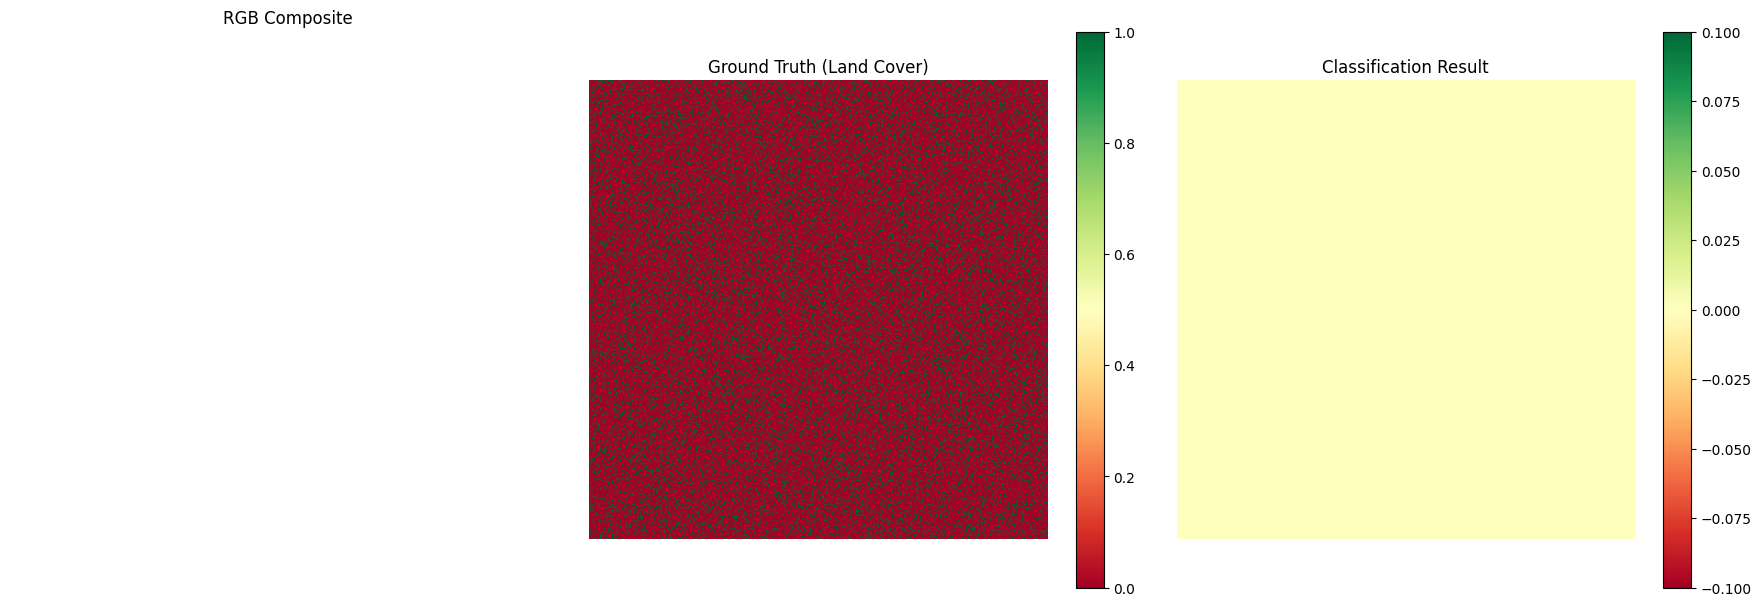

In [10]:
# Create RGB composite from hyperspectral data (approximate)
# Assuming bands roughly correspond to visible spectrum
rgb_bands = [20, 10, 0]  # Adjust based on your sensor bands
rgb_img = np.zeros((hyperspectral_data.shape[1], hyperspectral_data.shape[2], 3))
for i, band_idx in enumerate(rgb_bands):
    if band_idx < hyperspectral_data.shape[0]:
        rgb_img[:, :, i] = hyperspectral_data[band_idx, :, :]

# Normalize to 0-1 range
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RGB composite
axes[0].imshow(rgb_img)
axes[0].set_title('RGB Composite')
axes[0].axis('off')

# Ground truth
im1 = axes[1].imshow(pavement_mask, cmap='RdYlGn')
axes[1].set_title('Ground Truth (Land Cover)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

# Classification result
im2 = axes[2].imshow(classification_map, cmap='RdYlGn')
axes[2].set_title('Classification Result')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig('pavement_classification_results.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. Export Results

Export classification map as GeoTIFF.


In [11]:
# Export classification map
output_path = 'pavement_classification_map.tif'

# Update profile for single band classification map
output_profile = hyperspectral_profile.copy()
output_profile.update({
    'count': 1,
    'dtype': 'int16',
    'nodata': -999
})

with rasterio.open(output_path, 'w', **output_profile) as dst:
    dst.write(classification_map.astype('int16'), 1)

print(f"Classification map saved to: {output_path}")


Classification map saved to: pavement_classification_map.tif


## Summary

This notebook successfully identified pavements in the Brooklyn hyperspectral data using Random Forest classification with NYC land cover data as ground truth.

**Results:**
- Overall accuracy: (see output above)
- Classification map exported as GeoTIFF
- Visualizations saved

**Next Steps:**
- Fine-tune parameters if needed
- Process larger areas or full dataset
- Explore different classifiers or feature engineering
